# Torneo GNN 2025-26 — Predicción de Lipofilicidad de Moléculas

**Equipo:** GNN_MAPB_2026  
**Participantes:**
- Marco Apolo Pulpillo Berrocal

---

## Objetivo
Entrenar una red neuronal de grafos (GNN) que prediga la lipofilicidad de moléculas representadas como grafos.  
La métrica de evaluación principal es el **Mean Squared Error (MSE)**. Se minimizará probando diferentes arquitecturas.

## Estructura del notebook
1. Instalación de dependencias
2. Carga del dataset (local)
3. Análisis Exploratorio de Datos (EDA)
4. Funciones auxiliares (entrenamiento, evaluación, visualización)
5. **Experimento 1**: Línea base — GCN
6. **Experimento 2**: GIN con BatchNorm y LR scheduling
7. **Experimento 3**: GAT (Graph Attention Network)
8. **Experimento 4**: GIN Avanzado — Jumping Knowledge + Multi-scale Pooling
9. **Experimento 5**: K-Fold con mejor arquitectura + Ensemble
10. Comparación de resultados
11. Generación de predicciones para el torneo

---
## 1. Instalación de Dependencias

In [1]:
#!pip install torch_geometric --quiet

---
## 2. Importaciones y Configuración

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.nn import (
    Linear, BatchNorm1d, ReLU, Sequential, Module, Dropout
)

import networkx as nx
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils.convert import from_networkx
from torch_geometric.nn import (
    GCN, MLP,
    GCNConv, GATConv, GINConv, SAGEConv,
    global_add_pool, global_mean_pool, global_max_pool
)

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

sns.set_style('darkgrid')

# --- Reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando dispositivo: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Usando dispositivo: cuda
PyTorch version: 2.10.0+cu128


---
## 3. Carga del Dataset

Se carga el dataset directamente desde la carpeta local `nx_graphs/`.  
Si los archivos procesados ya existen en `./tournament_cache/processed/`, se cargan directamente (checkpoint automático).

In [3]:
class TournamentDataset(InMemoryDataset):
    """
    Dataset de moléculas para el torneo GNN 2025-26.
    Carga grafos GML desde una carpeta local.
    """

    def __init__(self, root, local_gml_dir, transform=None, pre_transform=None):
        self.local_gml_dir = local_gml_dir
        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(
            self.processed_paths[0], weights_only=False
        )
        self.train_idx = torch.load(self.processed_paths[1], weights_only=False)
        self.test_idx  = torch.load(self.processed_paths[2], weights_only=False)

    @property
    def raw_file_names(self):
        # Sin ficheros raw necesarios (datos ya locales)
        return []

    @property
    def processed_file_names(self):
        return ['data.pt', 'train_idx.pt', 'test_idx.pt']

    @property
    def num_features(self):
        return 9

    def download(self):
        pass  # Los datos están en local

    def process(self):
        print(f'Procesando grafos desde {self.local_gml_dir} ...')
        data_list = []
        train_idx = []
        test_idx  = []

        gml_files = [
            f for f in os.listdir(self.local_gml_dir)
            if f.endswith('.gml')
        ]

        for fname in gml_files:
            path = os.path.join(self.local_gml_dir, fname)
            G = nx.read_gml(path)
            data = from_networkx(G)
            data.x = data.x.float()
            data.nid = torch.tensor([G.graph['molecule_id']], dtype=torch.long)

            if G.graph['set'] == 'training':
                data.y = torch.tensor([G.graph['y']], dtype=torch.float)
                train_idx.append(G.graph['molecule_id'])
            else:
                data.y = torch.tensor([float('nan')], dtype=torch.float)
                test_idx.append(G.graph['molecule_id'])

            data_list.append(data)

        # Ordenar por molecule_id para que dataset[i] == molécula con id=i
        data_list.sort(key=lambda d: d.nid.item())

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        torch.save(train_idx, self.processed_paths[1])
        torch.save(test_idx,  self.processed_paths[2])
        print(f'  -> {len(train_idx)} moléculas de entrenamiento, {len(test_idx)} de test')

In [4]:
# Carga del dataset
# Si los archivos procesados ya existen, se cargan instantáneamente.

LOCAL_GML_DIR = '../data/nx_graphs'  # ruta relativa al notebook

dataset = TournamentDataset(root='../data/processed_cache', local_gml_dir=LOCAL_GML_DIR)

print(f'Total de moléculas:       {len(dataset)}')
print(f'Atributos por nodo:       {dataset.num_features}')
print(f'Ejemplo de grafo:         {dataset[0]}')
print(f'Moléculas de train:       {len(dataset.train_idx)}')
print(f'Moléculas de test:        {len(dataset.test_idx)}')

Total de moléculas:       4200
Atributos por nodo:       9
Ejemplo de grafo:         Data(x=[22, 9], edge_index=[2, 50], y=[1], molecule_id=[1], set='training', nid=[1])
Moléculas de train:       3360
Moléculas de test:        840


---
## 4. Análisis Exploratorio de Datos (EDA)

Distribución de lipofilicidad (train):
count    3360.000000
mean        2.200554
std         1.199276
min        -1.500000
25%         1.437500
50%         2.360000
75%         3.100000
max         4.500000


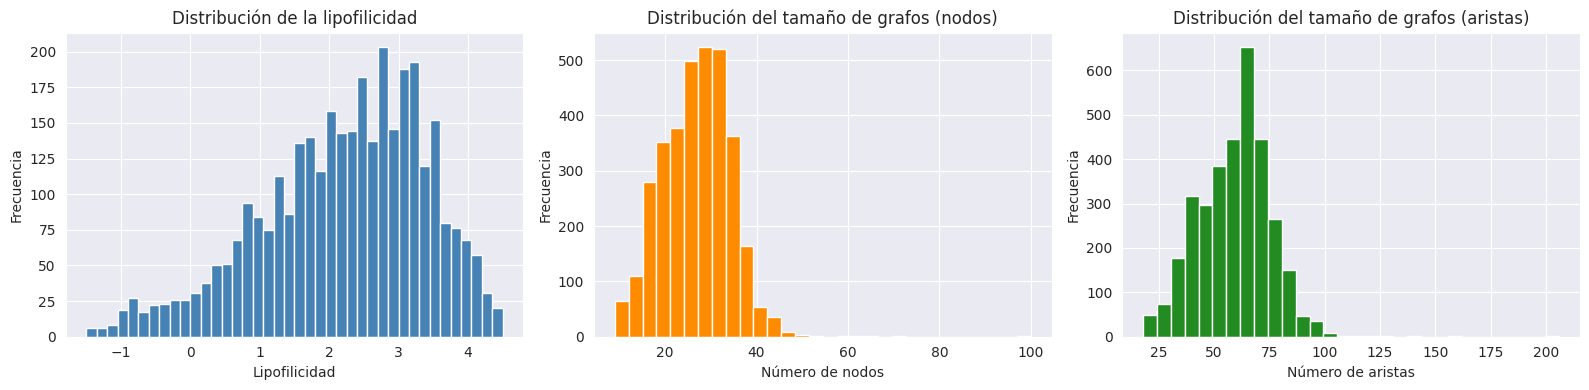


Mediana nodos: 27, Mediana aristas: 60


In [5]:
# Extraer etiquetas del conjunto de entrenamiento
y_train_all = [dataset[i].y.item() for i in dataset.train_idx]
print('Distribución de lipofilicidad (train):')
print(pd.Series(y_train_all).describe().to_string())

# Número de nodos y aristas por grafo
num_nodes = [dataset[i].num_nodes for i in dataset.train_idx]
num_edges = [dataset[i].num_edges for i in dataset.train_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train_all, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Lipofilicidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de la lipofilicidad')

axes[1].hist(num_nodes, bins=30, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Número de nodos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del tamaño de grafos (nodos)')

axes[2].hist(num_edges, bins=30, color='forestgreen', edgecolor='white')
axes[2].set_xlabel('Número de aristas')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución del tamaño de grafos (aristas)')

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nMediana nodos: {np.median(num_nodes):.0f}, Mediana aristas: {np.median(num_edges):.0f}')

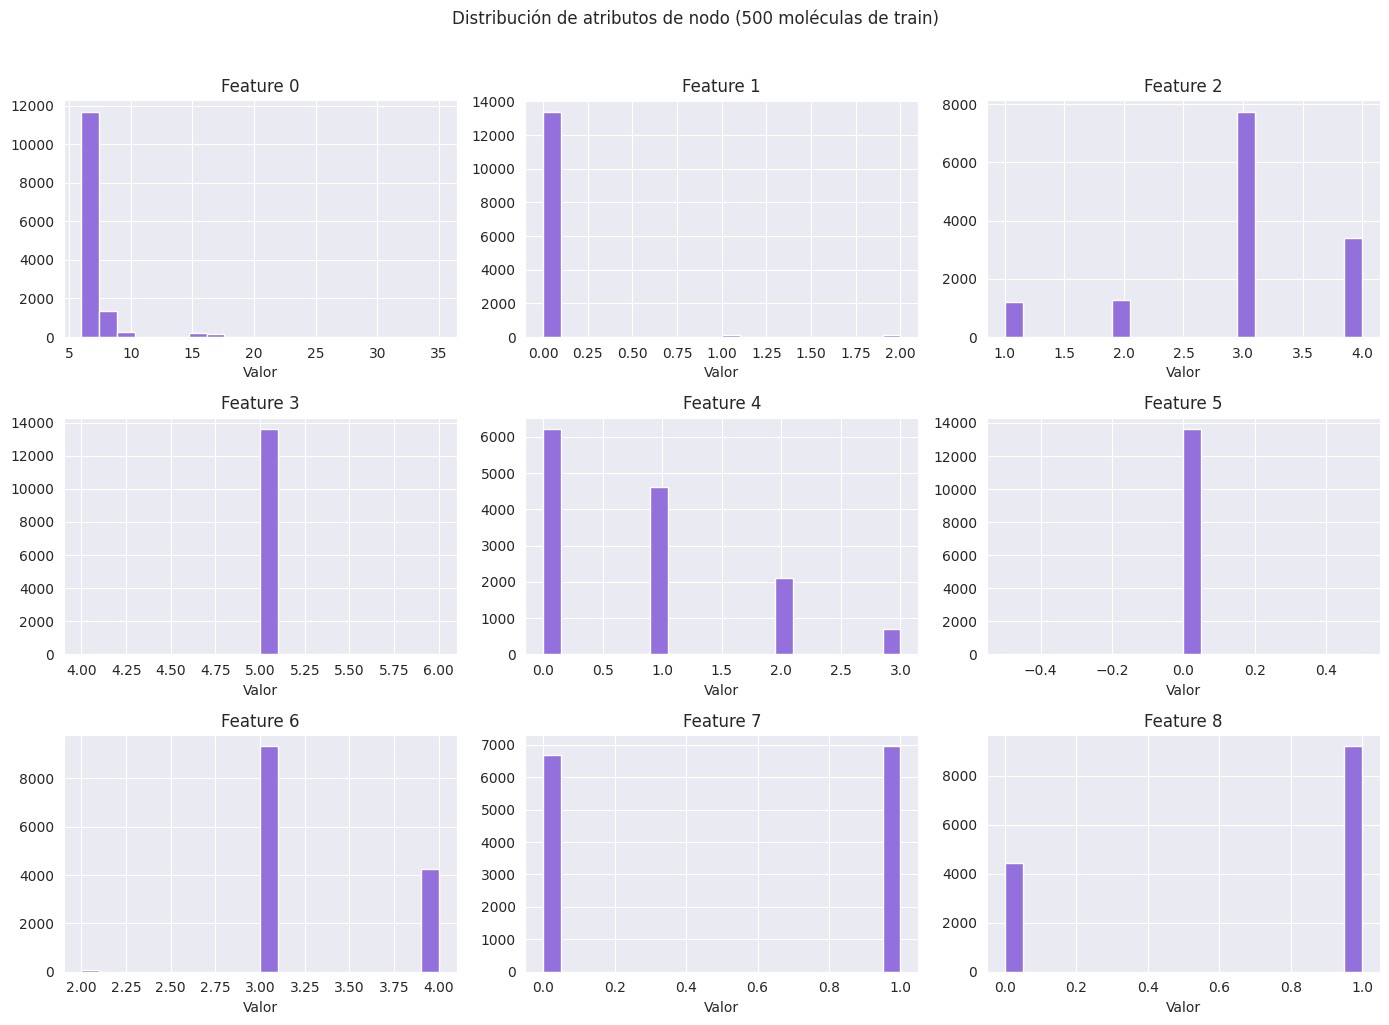

In [6]:
# Análisis de atributos de nodo (características)
X_all = torch.cat([dataset[i].x for i in dataset.train_idx[:500]], dim=0).numpy()
feature_names = [f'feat_{i}' for i in range(9)]
df_features = pd.DataFrame(X_all, columns=feature_names)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    ax.hist(df_features[f'feat_{i}'], bins=20, color='mediumpurple', edgecolor='white')
    ax.set_title(f'Feature {i}')
    ax.set_xlabel('Valor')
plt.suptitle('Distribución de atributos de nodo (500 moléculas de train)', y=1.02)
plt.tight_layout()
plt.savefig('eda_features.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Funciones Auxiliares

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_epoch(model, loader, optimizer, criterion, device):
    """Entrena el modelo durante una época y devuelve la pérdida media."""
    model.train()
    total_loss = 0.0
    total_graphs = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        y_pred = model(data).view(-1)
        y_true = data.y.view(-1)
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        total_graphs += data.num_graphs
    return total_loss / total_graphs


@torch.no_grad()
def evaluate(model, loader, device):
    """Evalúa el modelo y devuelve MSE, etiquetas reales y predicciones."""
    model.eval()
    y_pred_list, y_true_list = [], []
    for data in loader:
        data = data.to(device)
        out = model(data).view(-1)
        y_pred_list.extend(out.cpu().tolist())
        y_true_list.extend(data.y.view(-1).cpu().tolist())
    mse = mean_squared_error(y_true_list, y_pred_list)
    return mse, y_true_list, y_pred_list


def train_model(
    model, train_loader, val_loader, optimizer, criterion, scheduler=None,
    n_epochs=500, patience=50, device='cpu', verbose=True, checkpoint_path=None
):
    """
    Entrenamiento completo con early stopping y guardado del mejor modelo.
    Devuelve: (train_losses, val_mses, best_val_mse, best_epoch)
    """
    best_val_mse = float('inf')
    best_epoch   = 0
    patience_cnt = 0
    train_losses = []
    val_mses     = []
    best_state   = None

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_mse, _, _ = evaluate(model, val_loader, device)

        train_losses.append(train_loss)
        val_mses.append(val_mse)

        # Scheduler step
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_mse)
            else:
                scheduler.step()

        # Guardar mejor modelo
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_epoch   = epoch
            patience_cnt = 0
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)
        else:
            patience_cnt += 1

        if verbose and epoch % 50 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch:4d} | Loss: {train_loss:.4f} | Val MSE: {val_mse:.4f} '
                  f'| Best MSE: {best_val_mse:.4f} (ep {best_epoch}) | LR: {lr:.6f}')

        if patience_cnt >= patience:
            if verbose:
                print(f'  Early stopping en epoch {epoch} (mejor epoch: {best_epoch})')
            break

    # Restaurar el mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_mses, best_val_mse, best_epoch


def plot_training_curves(train_losses, val_mses, title=''):
    """Visualiza las curvas de entrenamiento."""
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, train_losses, label='Train Loss', color='steelblue')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Pérdida')
    axes[0].set_title(f'Pérdida de entrenamiento — {title}')
    axes[0].legend()

    axes[1].plot(epochs, val_mses, label='Val MSE', color='darkorange')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('MSE')
    axes[1].set_title(f'MSE de validación — {title}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'curvas_{title.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()


def plot_predictions(y_true, y_pred, title=''):
    """Visualiza predicciones vs valores reales y residuos."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    residuals = y_pred - y_true

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].scatter(y_true, y_pred, alpha=0.4, s=15)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5)
    axes[0].set_xlabel('Valor real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title(f'Real vs Predicho — {title}')

    axes[1].scatter(y_true, residuals, alpha=0.4, s=15)
    axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Valor real')
    axes[1].set_ylabel('Residuo (Pred − Real)')
    axes[1].set_title(f'Residuos — {title}')

    plt.tight_layout()
    plt.savefig(f'pred_{title.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()


# Diccionario para almacenar todos los resultados
results_summary = {}
print('Funciones auxiliares cargadas correctamente.')

Funciones auxiliares cargadas correctamente.


In [8]:
# División train / validación
train_idx, val_idx = train_test_split(
    dataset.train_idx, test_size=0.15, random_state=SEED
)

print(f'Train: {len(train_idx)} | Validación: {len(val_idx)}')

y_train = [dataset[i].y.item() for i in train_idx]
y_val   = [dataset[i].y.item() for i in val_idx]
print(f'Train → media: {np.mean(y_train):.3f}, std: {np.std(y_train):.3f}')
print(f'Val   → media: {np.mean(y_val):.3f},   std: {np.std(y_val):.3f}')

Train: 2856 | Validación: 504
Train → media: 2.192, std: 1.205
Val   → media: 2.249,   std: 1.162


---
## 6. Experimento 1 — Línea Base: GCN

Reproducción exacta de la arquitectura propuesta en clase:
- **GCN** de 3 capas, `hidden_channels=64`, `dropout=0.5`
- **Pooling**: `global_add_pool`
- **MLP** clasificador de 2 capas
- **Pérdida**: `HuberLoss`
- **Optimizador**: Adam lr=0.001
- **Épocas**: 500 (sin early stopping)

In [9]:
from torch_geometric.nn import GCN, MLP, global_add_pool

class GCNGraph(Module):
    """GCN con global_add_pool y MLP clasificador — arquitectura de clase."""

    def __init__(self, num_features, num_classes=1, hidden_channels=64, n_layers=3):
        super().__init__()
        self.gcn = GCN(
            in_channels=num_features,
            hidden_channels=hidden_channels,
            num_layers=n_layers,
            out_channels=hidden_channels,
            dropout=0.5
        )
        self.cls = MLP(
            in_channels=hidden_channels,
            hidden_channels=hidden_channels,
            out_channels=num_classes,
            num_layers=2,
            dropout=0.5
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.gcn(x.float(), edge_index)
        x = global_add_pool(x, batch)
        x = self.cls(x)
        return x

print('Modelo GCN Baseline definido.')

Modelo GCN Baseline definido.


In [10]:
# Entrenamiento Experimento 1 — GCN Baseline
set_seed(SEED)

train_loader_gcn = DataLoader(dataset[train_idx], batch_size=512, shuffle=True)
val_loader_gcn   = DataLoader(dataset[val_idx],   batch_size=512, shuffle=False)

model_gcn = GCNGraph(dataset.num_features, 1).to(DEVICE)
optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.001, weight_decay=5e-4)
criterion_gcn = torch.nn.HuberLoss()

print(f'Parámetros GCN: {sum(p.numel() for p in model_gcn.parameters()):,}')
print('Entrenando GCN Baseline...')

train_losses_gcn, val_mses_gcn, best_mse_gcn, best_ep_gcn = train_model(
    model_gcn, train_loader_gcn, val_loader_gcn,
    optimizer_gcn, criterion_gcn,
    scheduler=None, n_epochs=500, patience=500,   # Sin early stopping (igual que en clase)
    device=DEVICE, verbose=True,
    checkpoint_path='../models/checkpoint_gcn.pt'
)

_, y_true_gcn, y_pred_gcn = evaluate(model_gcn, val_loader_gcn, DEVICE)
mse_gcn = mean_squared_error(y_true_gcn, y_pred_gcn)
results_summary['Exp1_GCN_Baseline'] = {'MSE': mse_gcn, 'best_epoch': best_ep_gcn}
print(f'\n==> MSE validación GCN Baseline: {mse_gcn:.4f}')

Parámetros GCN: 13,313
Entrenando GCN Baseline...
Epoch   50 | Loss: 0.6403 | Val MSE: 1.4715 | Best MSE: 1.2347 (ep 20) | LR: 0.001000
Epoch  100 | Loss: 0.6087 | Val MSE: 1.3973 | Best MSE: 1.2347 (ep 20) | LR: 0.001000
Epoch  150 | Loss: 0.5769 | Val MSE: 1.3543 | Best MSE: 1.2347 (ep 20) | LR: 0.001000
Epoch  200 | Loss: 0.5383 | Val MSE: 1.1888 | Best MSE: 1.1353 (ep 199) | LR: 0.001000
Epoch  250 | Loss: 0.4890 | Val MSE: 0.9867 | Best MSE: 0.9867 (ep 250) | LR: 0.001000
Epoch  300 | Loss: 0.4420 | Val MSE: 0.9309 | Best MSE: 0.8769 (ep 294) | LR: 0.001000
Epoch  350 | Loss: 0.4329 | Val MSE: 0.8143 | Best MSE: 0.8143 (ep 350) | LR: 0.001000
Epoch  400 | Loss: 0.4115 | Val MSE: 0.7975 | Best MSE: 0.7942 (ep 378) | LR: 0.001000
Epoch  450 | Loss: 0.3964 | Val MSE: 0.7737 | Best MSE: 0.7605 (ep 444) | LR: 0.001000
Epoch  500 | Loss: 0.3863 | Val MSE: 0.7937 | Best MSE: 0.7505 (ep 498) | LR: 0.001000

==> MSE validación GCN Baseline: 0.7505


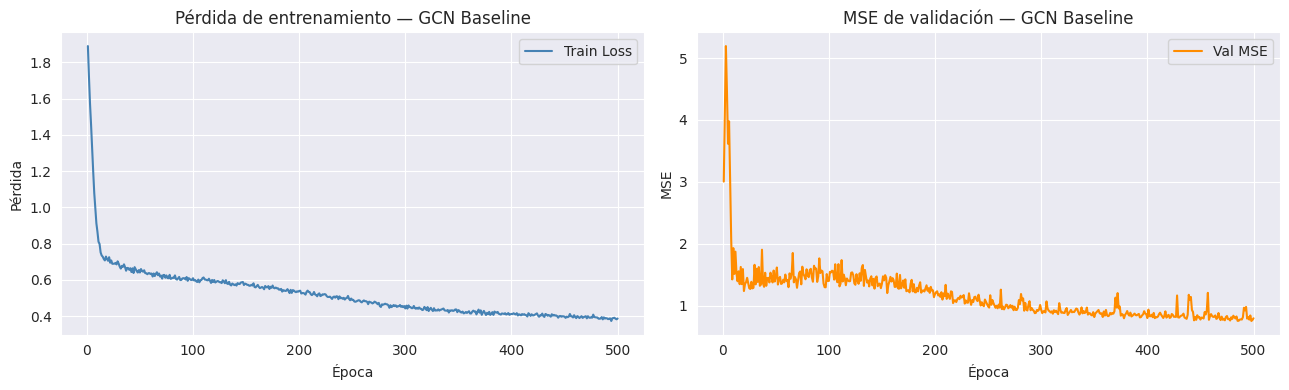

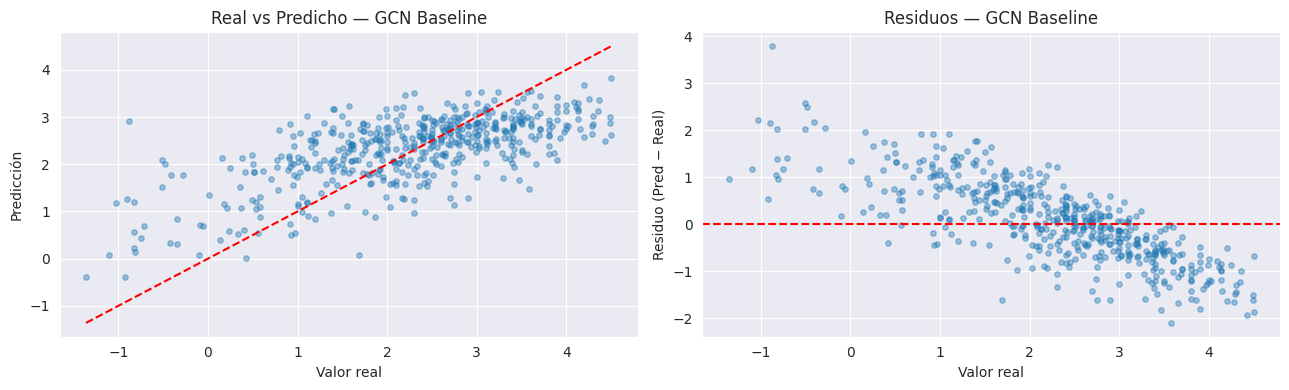

In [11]:
plot_training_curves(train_losses_gcn, val_mses_gcn, title='GCN Baseline')
plot_predictions(y_true_gcn, y_pred_gcn, title='GCN Baseline')

---
## 7. Experimento 2 — GIN con BatchNorm y LR Scheduling

**Graph Isomorphism Network (GIN)** (Xu et al., 2018) es teóricamente más expresivo que GCN:  
usa agregación suma (la más discriminativa según el test de Weisfeiler-Lehman) y redes MLP internas.

Mejoras respecto al baseline:
- **GINConv** con `train_eps=True` (ε aprendible)
- **BatchNorm** después de cada capa de convolución
- **4 capas**, `hidden=128`
- **Pérdida**: MSELoss (métrica directa del torneo)
- **ReduceLROnPlateau**: reduce el LR cuando el val MSE no mejora
- **Early stopping** (patience=75)

In [12]:
class GINGraph(Module):
    """
    Graph Isomorphism Network (GIN) con BatchNorm.
    - GINConv con MLP interno y eps aprendible
    - BatchNorm + ReLU + Dropout después de cada capa
    - global_add_pool
    - MLP regresor final
    """

    def __init__(self, num_features, hidden_channels=128, n_layers=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.convs = torch.nn.ModuleList()
        self.bns   = torch.nn.ModuleList()

        # Primera capa: num_features -> hidden_channels
        mlp_in = Sequential(
            Linear(num_features, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.convs.append(GINConv(mlp_in, train_eps=True))
        self.bns.append(BatchNorm1d(hidden_channels))

        # Capas ocultas: hidden_channels -> hidden_channels
        for _ in range(n_layers - 1):
            mlp_h = Sequential(
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU(),
                Linear(hidden_channels, hidden_channels)
            )
            self.convs.append(GINConv(mlp_h, train_eps=True))
            self.bns.append(BatchNorm1d(hidden_channels))

        # MLP regresor
        self.mlp = Sequential(
            Linear(hidden_channels, hidden_channels // 2),
            BatchNorm1d(hidden_channels // 2),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = global_add_pool(x, batch)   # Suma sobre nodos
        x = self.mlp(x)
        return x

print('Modelo GIN definido.')

Modelo GIN definido.


In [13]:
# Entrenamiento Experimento 2 — GIN
set_seed(SEED)

train_loader_gin = DataLoader(dataset[train_idx], batch_size=256, shuffle=True)
val_loader_gin   = DataLoader(dataset[val_idx],   batch_size=512, shuffle=False)

model_gin = GINGraph(
    num_features=dataset.num_features,
    hidden_channels=128,
    n_layers=4,
    dropout=0.3
).to(DEVICE)

optimizer_gin = torch.optim.Adam(model_gin.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_gin = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gin, mode='min', factor=0.5, patience=20, min_lr=1e-5
)
criterion_gin = torch.nn.MSELoss()

print(f'Parámetros GIN: {sum(p.numel() for p in model_gin.parameters()):,}')
print('Entrenando GIN...')

train_losses_gin, val_mses_gin, best_mse_gin, best_ep_gin = train_model(
    model_gin, train_loader_gin, val_loader_gin,
    optimizer_gin, criterion_gin, scheduler=scheduler_gin,
    n_epochs=600, patience=75,
    device=DEVICE, verbose=True,
    checkpoint_path='../models/checkpoint_gin.pt'
)

_, y_true_gin, y_pred_gin = evaluate(model_gin, val_loader_gin, DEVICE)
mse_gin = mean_squared_error(y_true_gin, y_pred_gin)
results_summary['Exp2_GIN_BatchNorm'] = {'MSE': mse_gin, 'best_epoch': best_ep_gin}
print(f'\n==> MSE validación GIN: {mse_gin:.4f}')

Parámetros GIN: 127,365
Entrenando GIN...
Epoch   50 | Loss: 0.6815 | Val MSE: 0.6602 | Best MSE: 0.6022 (ep 46) | LR: 0.001000
Epoch  100 | Loss: 0.4641 | Val MSE: 0.4976 | Best MSE: 0.4744 (ep 95) | LR: 0.000500
Epoch  150 | Loss: 0.4042 | Val MSE: 0.4643 | Best MSE: 0.4486 (ep 143) | LR: 0.000500
Epoch  200 | Loss: 0.3372 | Val MSE: 0.4267 | Best MSE: 0.4267 (ep 200) | LR: 0.000125
Epoch  250 | Loss: 0.3436 | Val MSE: 0.4288 | Best MSE: 0.4204 (ep 222) | LR: 0.000063
Epoch  300 | Loss: 0.3027 | Val MSE: 0.4267 | Best MSE: 0.4162 (ep 283) | LR: 0.000031
Epoch  350 | Loss: 0.3191 | Val MSE: 0.4269 | Best MSE: 0.4162 (ep 283) | LR: 0.000010
  Early stopping en epoch 358 (mejor epoch: 283)

==> MSE validación GIN: 0.4162


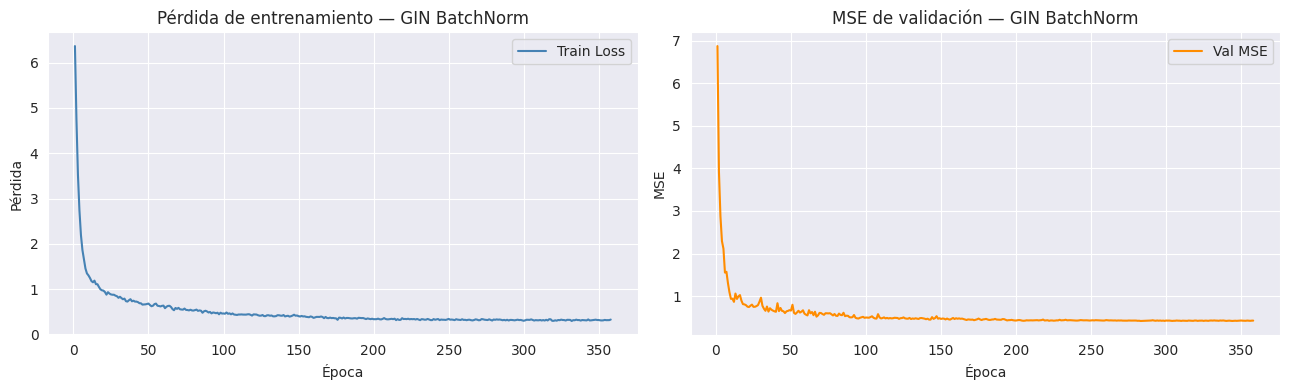

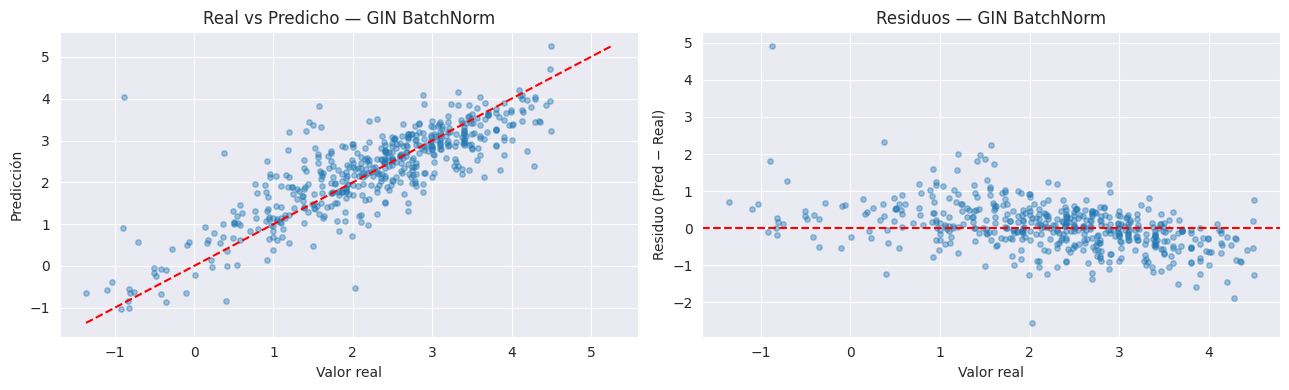

In [14]:
plot_training_curves(train_losses_gin, val_mses_gin, title='GIN BatchNorm')
plot_predictions(y_true_gin, y_pred_gin, title='GIN BatchNorm')

---
## 8. Experimento 3 — GAT (Graph Attention Network)

**Graph Attention Network (GAT)** (Veličković et al., 2018) aprende a asignar pesos de atención  
a cada vecino, permitiendo que el modelo focalice en los átomos más relevantes para predecir lipofilicidad.

Arquitectura:
- **GATConv** multi-cabeza (`heads=4`)
- **BatchNorm** después de cada capa
- **3 capas**, `hidden=128`
- **Pooling**: `global_mean_pool`
- **Pérdida**: MSELoss + ReduceLROnPlateau + early stopping

In [15]:
class GATGraph(Module):
    """
    Graph Attention Network (GAT) con BatchNorm.
    - Atención multi-cabeza
    - BatchNorm + ELU + Dropout
    - global_mean_pool
    """

    def __init__(self, num_features, hidden_channels=128, n_layers=3, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()

        # Primera capa
        self.convs.append(GATConv(num_features, hidden_channels // heads,
                                  heads=heads, dropout=dropout, concat=True))
        self.bns.append(BatchNorm1d(hidden_channels))

        # Capas intermedias
        for _ in range(n_layers - 2):
            self.convs.append(GATConv(hidden_channels, hidden_channels // heads,
                                      heads=heads, dropout=dropout, concat=True))
            self.bns.append(BatchNorm1d(hidden_channels))

        # Última capa (1 cabeza de salida)
        self.convs.append(GATConv(hidden_channels, hidden_channels,
                                  heads=1, dropout=dropout, concat=False))
        self.bns.append(BatchNorm1d(hidden_channels))

        # MLP regresor
        self.mlp = Sequential(
            Linear(hidden_channels, hidden_channels // 2),
            BatchNorm1d(hidden_channels // 2),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = global_mean_pool(x, batch)  # Media sobre nodos
        x = self.mlp(x)
        return x

print('Modelo GAT definido.')

Modelo GAT definido.


In [16]:
# Entrenamiento Experimento 3 — GAT
set_seed(SEED)

train_loader_gat = DataLoader(dataset[train_idx], batch_size=256, shuffle=True)
val_loader_gat   = DataLoader(dataset[val_idx],   batch_size=512, shuffle=False)

model_gat = GATGraph(
    num_features=dataset.num_features,
    hidden_channels=128,
    n_layers=3,
    heads=4,
    dropout=0.3
).to(DEVICE)

optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_gat = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gat, mode='min', factor=0.5, patience=20, min_lr=1e-5
)
criterion_gat = torch.nn.MSELoss()

print(f'Parámetros GAT: {sum(p.numel() for p in model_gat.parameters()):,}')
print('Entrenando GAT...')

train_losses_gat, val_mses_gat, best_mse_gat, best_ep_gat = train_model(
    model_gat, train_loader_gat, val_loader_gat,
    optimizer_gat, criterion_gat, scheduler=scheduler_gat,
    n_epochs=600, patience=75,
    device=DEVICE, verbose=True,
    checkpoint_path='../models/checkpoint_gat.pt'
)

_, y_true_gat, y_pred_gat = evaluate(model_gat, val_loader_gat, DEVICE)
mse_gat = mean_squared_error(y_true_gat, y_pred_gat)
results_summary['Exp3_GAT'] = {'MSE': mse_gat, 'best_epoch': best_ep_gat}
print(f'\n==> MSE validación GAT: {mse_gat:.4f}')

Parámetros GAT: 44,289
Entrenando GAT...
Epoch   50 | Loss: 1.3880 | Val MSE: 1.1602 | Best MSE: 1.0532 (ep 49) | LR: 0.001000
Epoch  100 | Loss: 1.1737 | Val MSE: 0.9651 | Best MSE: 0.8804 (ep 86) | LR: 0.001000
Epoch  150 | Loss: 1.0386 | Val MSE: 0.8299 | Best MSE: 0.7896 (ep 141) | LR: 0.001000
Epoch  200 | Loss: 0.9279 | Val MSE: 0.6996 | Best MSE: 0.6697 (ep 195) | LR: 0.000500
Epoch  250 | Loss: 0.8831 | Val MSE: 0.6599 | Best MSE: 0.6543 (ep 235) | LR: 0.000250
Epoch  300 | Loss: 0.8849 | Val MSE: 0.6639 | Best MSE: 0.6403 (ep 299) | LR: 0.000125
Epoch  350 | Loss: 0.8980 | Val MSE: 0.6579 | Best MSE: 0.6392 (ep 341) | LR: 0.000063
Epoch  400 | Loss: 0.8573 | Val MSE: 0.6449 | Best MSE: 0.6392 (ep 341) | LR: 0.000016
  Early stopping en epoch 416 (mejor epoch: 341)

==> MSE validación GAT: 0.6392


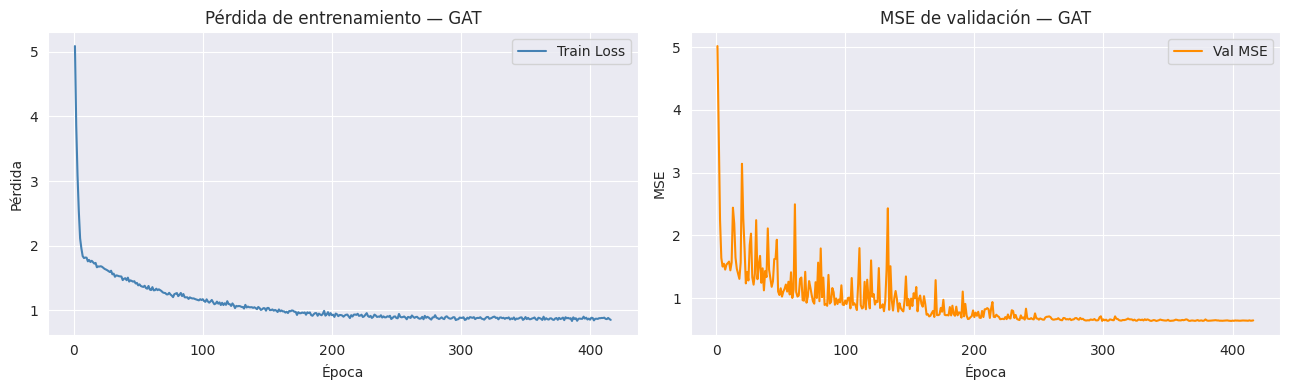

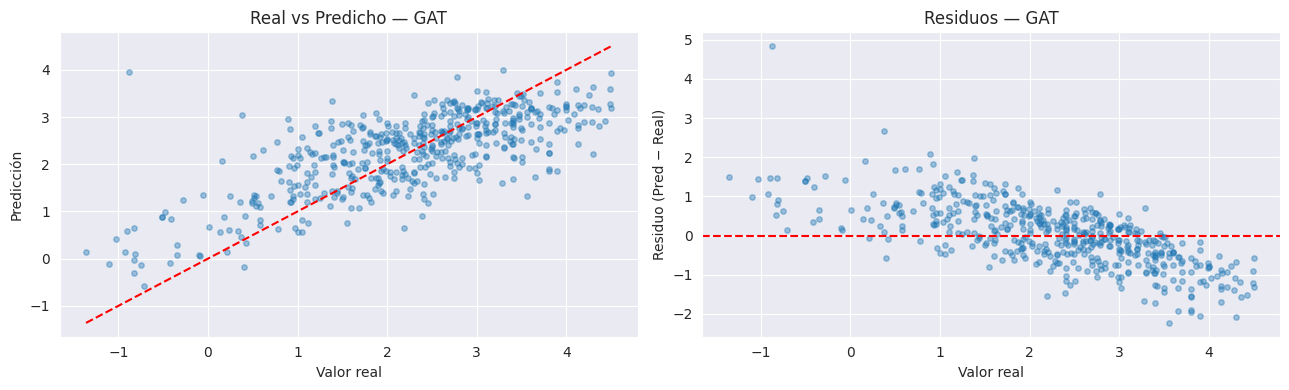

In [17]:
plot_training_curves(train_losses_gat, val_mses_gat, title='GAT')
plot_predictions(y_true_gat, y_pred_gat, title='GAT')

---
## 9. Experimento 4 — GIN Avanzado: Jumping Knowledge + Multi-Scale Pooling

Esta es la arquitectura más avanzada del experimento, combinando varias técnicas:

1. **Conexiones residuales**: evitan el problema de vanishing gradient y permiten capas más profundas.
2. **Jumping Knowledge (JK)** (Xu et al., 2018): concatena las representaciones de **todas las capas**,  
   capturando información a múltiples escalas de vecindad.
3. **Multi-scale pooling**: para cada capa, combina `add_pool + mean_pool + max_pool`  
   → representación más rica del grafo.
4. **5 capas** GIN, `hidden=256`, `dropout=0.2`.
5. **CosineAnnealingLR**: decaimiento suave del learning rate.
6. **Early stopping** (patience=100).

In [18]:
class AdvancedGINGraph(Module):
    """
    GIN avanzado con:
    - Conexiones residuales entre capas
    - Jumping Knowledge: concatena representaciones de todas las capas
    - Multi-scale pooling por capa: add + mean + max
    - MLP regresor con BatchNorm y Dropout
    """

    def __init__(self, num_features, hidden_channels=256, n_layers=5, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.n_layers = n_layers

        # Proyección inicial de features -> hidden_channels
        self.input_proj = Sequential(
            Linear(num_features, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU()
        )

        self.convs = torch.nn.ModuleList()
        self.bns   = torch.nn.ModuleList()

        for _ in range(n_layers):
            # MLP interno de la capa GIN
            mlp = Sequential(
                Linear(hidden_channels, hidden_channels * 2),
                BatchNorm1d(hidden_channels * 2),
                ReLU(),
                Linear(hidden_channels * 2, hidden_channels)
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(BatchNorm1d(hidden_channels))

        # JK: n_layers capas x 3 poolings x hidden_channels
        jk_dim = n_layers * hidden_channels * 3

        self.mlp_head = Sequential(
            Linear(jk_dim, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels, hidden_channels // 2),
            BatchNorm1d(hidden_channels // 2),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        x = self.input_proj(x)

        layer_reps = []  # Representaciones de cada capa para JK

        for conv, bn in zip(self.convs, self.bns):
            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = x_new + x  # Conexión residual

            # Multi-scale pooling para esta capa
            rep = torch.cat([
                global_add_pool(x, batch),
                global_mean_pool(x, batch),
                global_max_pool(x, batch)
            ], dim=1)  # [B, hidden_channels * 3]
            layer_reps.append(rep)

        # Jumping Knowledge: concatenar todas las capas
        out = torch.cat(layer_reps, dim=1)  # [B, n_layers * hidden_channels * 3]
        out = self.mlp_head(out)
        return out

print('Modelo GIN Avanzado (JK + Multi-scale Pooling) definido.')

Modelo GIN Avanzado (JK + Multi-scale Pooling) definido.


In [20]:
# Entrenamiento Experimento 4 — GIN Avanzado
set_seed(SEED)

train_loader_adv = DataLoader(dataset[train_idx], batch_size=128, shuffle=True)
val_loader_adv   = DataLoader(dataset[val_idx],   batch_size=512, shuffle=False)

model_adv = AdvancedGINGraph(
    num_features=dataset.num_features,
    hidden_channels=256,
    n_layers=5,
    dropout=0.2
).to(DEVICE)

optimizer_adv = torch.optim.Adam(model_adv.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_adv = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adv, T_max=300, eta_min=1e-5
)
criterion_adv = torch.nn.MSELoss()

print(f'Parámetros GIN Avanzado: {sum(p.numel() for p in model_adv.parameters()):,}')
print('Entrenando GIN Avanzado...')

train_losses_adv, val_mses_adv, best_mse_adv, best_ep_adv = train_model(
    model_adv, train_loader_adv, val_loader_adv,
    optimizer_adv, criterion_adv, scheduler=scheduler_adv,
    n_epochs=700, patience=100,
    device=DEVICE, verbose=True,
    checkpoint_path='../models/checkpoint_adv.pt'
)

_, y_true_adv, y_pred_adv = evaluate(model_adv, val_loader_adv, DEVICE)
mse_adv = mean_squared_error(y_true_adv, y_pred_adv)
results_summary['Exp4_GIN_Avanzado_JK'] = {'MSE': mse_adv, 'best_epoch': best_ep_adv}
print(f'\n==> MSE validación GIN Avanzado: {mse_adv:.4f}')

Parámetros GIN Avanzado: 2,342,406
Entrenando GIN Avanzado...


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch   50 | Loss: 0.2432 | Val MSE: 0.4400 | Best MSE: 0.3995 (ep 48) | LR: 0.000934


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  100 | Loss: 0.1680 | Val MSE: 0.4035 | Best MSE: 0.3615 (ep 93) | LR: 0.000752


...

Epoch  300 | Loss: 0.0734 | Val MSE: 0.3101 | Best MSE: 0.3030 (ep 263) | LR: 0.000010


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  350 | Loss: 0.0648 | Val MSE: 0.3108 | Best MSE: 0.3030 (ep 263) | LR: 0.000076


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

  Early stopping en epoch 363 (mejor epoch: 263)

==> MSE validación GIN Avanzado: 0.3030


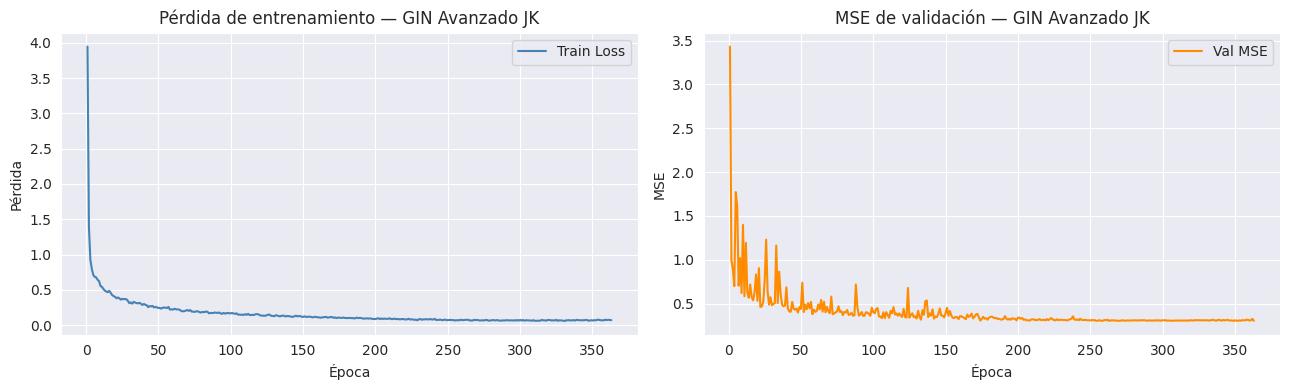

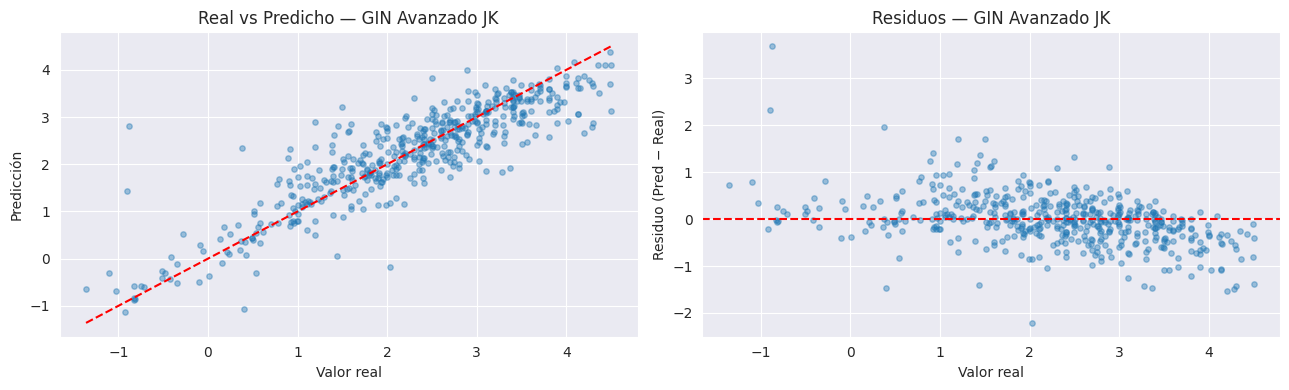

In [21]:
plot_training_curves(train_losses_adv, val_mses_adv, title='GIN Avanzado JK')
plot_predictions(y_true_adv, y_pred_adv, title='GIN Avanzado JK')

---
## 10. Experimento 5 — K-Fold Cross-Validation con Mejor Arquitectura + Ensemble

Se aplica **5-Fold Cross-Validation** con la mejor arquitectura (GIN Avanzado) para:
1. Obtener una estimación más robusta del MSE.
2. Entrenar 5 modelos que se combinan como **ensemble** (promedio) para las predicciones finales,  
   reduciendo la varianza.

> **Nota**: Se usan todos los datos de `train_idx` (3360 moléculas) para la CV.

In [22]:
# K-Fold Cross-Validation + Ensemble
set_seed(SEED)

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

all_train_idx = np.array(dataset.train_idx)
fold_mses = []
kfold_models = []  # Guardar todos los modelos para ensemble

for fold, (tr_idx, vl_idx) in enumerate(kf.split(all_train_idx)):
    print(f'\n========== FOLD {fold + 1}/{N_FOLDS} ==========')
    set_seed(SEED + fold)

    fold_train_ids = all_train_idx[tr_idx].tolist()
    fold_val_ids   = all_train_idx[vl_idx].tolist()

    fold_train_loader = DataLoader(dataset[fold_train_ids], batch_size=128, shuffle=True)
    fold_val_loader   = DataLoader(dataset[fold_val_ids],   batch_size=512, shuffle=False)

    model_fold = AdvancedGINGraph(
        num_features=dataset.num_features,
        hidden_channels=256,
        n_layers=5,
        dropout=0.2
    ).to(DEVICE)

    opt_fold = torch.optim.Adam(model_fold.parameters(), lr=1e-3, weight_decay=1e-4)
    sch_fold = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_fold, T_max=300, eta_min=1e-5
    )
    crit_fold = torch.nn.MSELoss()

    _, _, fold_best_mse, fold_best_ep = train_model(
        model_fold, fold_train_loader, fold_val_loader,
        opt_fold, crit_fold, scheduler=sch_fold,
        n_epochs=500, patience=75,
        device=DEVICE, verbose=True,
        checkpoint_path=f'../models/checkpoint_kfold_{fold}.pt'
    )

    _, y_t, y_p = evaluate(model_fold, fold_val_loader, DEVICE)
    fold_mse = mean_squared_error(y_t, y_p)
    fold_mses.append(fold_mse)
    kfold_models.append(model_fold)
    print(f'  Fold {fold + 1} MSE: {fold_mse:.4f} (mejor epoch: {fold_best_ep})')

kfold_mean_mse = np.mean(fold_mses)
kfold_std_mse  = np.std(fold_mses)
results_summary['Exp5_KFold_Ensemble'] = {
    'MSE': kfold_mean_mse,
    'std': kfold_std_mse,
    'fold_mses': fold_mses
}

print(f'\n==> K-Fold MSE: {kfold_mean_mse:.4f} ± {kfold_std_mse:.4f}')
print(f'    Resultados por fold: {[f"{m:.4f}" for m in fold_mses]}')


========== FOLD 1/5 ==========


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch   50 | Loss: 0.2498 | Val MSE: 0.4059 | Best MSE: 0.4059 (ep 50) | LR: 0.000934


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  100 | Loss: 0.1550 | Val MSE: 0.4597 | Best MSE: 0.3473 (ep 94) | LR: 0.000752


...

Epoch  250 | Loss: 0.0695 | Val MSE: 0.3266 | Best MSE: 0.3171 (ep 234) | LR: 0.000076


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  300 | Loss: 0.0605 | Val MSE: 0.3207 | Best MSE: 0.3171 (ep 234) | LR: 0.000010


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

  Early stopping en epoch 309 (mejor epoch: 234)
  Fold 5 MSE: 0.3171 (mejor epoch: 234)

==> K-Fold MSE: 0.3055 ± 0.0108
    Resultados por fold: ['0.2975', '0.3052', '0.2900', '0.3175', '0.3171']


---
## 12. Generación de Predicciones para el Torneo

Se usa el **ensemble de 5 modelos K-Fold** para generar predicciones sobre el conjunto de test.  
El promedio de las 5 predicciones reduce la varianza respecto a un único modelo.

In [24]:
# Generar predicciones para el torneo
@torch.no_grad()
def predict_ensemble(models, loader, device):
    """Genera predicciones como promedio de un ensemble de modelos."""
    all_preds = []  # lista de predicciones por modelo
    nids = []

    for model in models:
        model.eval()
        model.to(device)

    first = True
    model_preds = [[] for _ in models]

    for data in loader:
        data = data.to(device)
        if first:
            nids.extend(data.nid.cpu().tolist())

        for i, model in enumerate(models):
            out = model(data).view(-1).cpu().tolist()
            model_preds[i].extend(out)
        first = False

    # Promedio del ensemble
    avg_preds = np.mean(model_preds, axis=0).tolist()
    return nids, avg_preds


test_loader = DataLoader(
    dataset[dataset.test_idx], batch_size=512, shuffle=False
)

# Usar ensemble K-Fold
nids, predictions = predict_ensemble(kfold_models, test_loader, DEVICE)

# Guardar predicciones
output = {'nid': nids, 'y': predictions}
with open('test_predictions_ensemble.json', 'w') as f:
    json.dump(output, f, indent=4)

print(f'Predicciones guardadas en test_predictions_ensemble.json')
print(f'Número de predicciones: {len(nids)}')
print(f'Distribución: media={np.mean(predictions):.3f}, std={np.std(predictions):.3f}')
print(f'  min={np.min(predictions):.3f}, max={np.max(predictions):.3f}')

Predicciones guardadas en test_predictions_ensemble.json
Número de predicciones: 512
Distribución: media=2.161, std=1.089
  min=-2.892, max=4.371


Predicciones del modelo individual guardadas en test_predictions_single.json


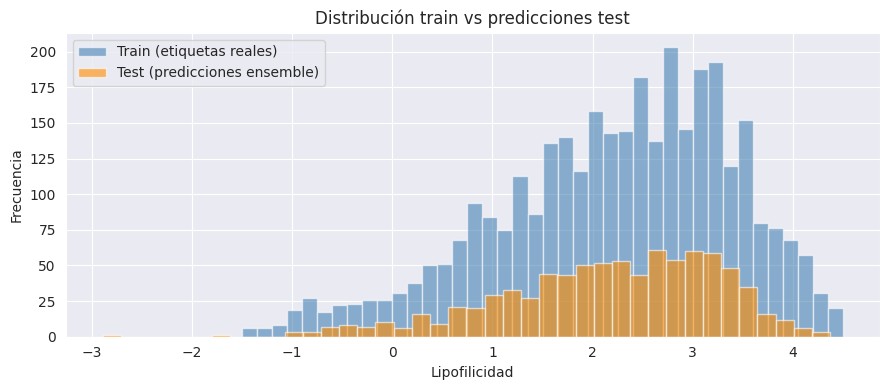

In [25]:
# También guardar predicciones del mejor modelo individual (GIN Avanzado)
@torch.no_grad()
def predict_single(model, loader, device):
    model.eval()
    model.to(device)
    nids, preds = [], []
    for data in loader:
        data = data.to(device)
        out = model(data).view(-1).cpu().tolist()
        preds.extend(out)
        nids.extend(data.nid.cpu().tolist())
    return nids, preds

nids_single, preds_single = predict_single(model_adv, test_loader, DEVICE)
with open('test_predictions_single.json', 'w') as f:
    json.dump({'nid': nids_single, 'y': preds_single}, f, indent=4)

print('Predicciones del modelo individual guardadas en test_predictions_single.json')

# Visualización de la distribución de predicciones vs train
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_train_all, bins=40, alpha=0.6, label='Train (etiquetas reales)', color='steelblue')
ax.hist(predictions, bins=40, alpha=0.6, label='Test (predicciones ensemble)', color='darkorange')
ax.set_xlabel('Lipofilicidad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución train vs predicciones test')
ax.legend()
plt.tight_layout()
plt.savefig('distribucion_predicciones.png', dpi=100, bbox_inches='tight')
plt.show()



  ## 14. Experimento 6 — GIN + Nodo Virtual (Virtual Node)

  El **nodo virtual** (Gilmer et al., 2017; ampliamente usado en OGB) añade un
  nodo especial
  conectado bidireccionalmente a todos los nodos del grafo. Funciona como un
  "canal de broadcast"
  global: en cada capa, el nodo virtual agrega información de todos los nodos
  reales y luego
  la redistribuye. Esto permite comunicación global en un solo salto,
  complementando la
  propagación local de GIN.

  Se combina con JK + multi-scale pooling del Experimento 4.




In [28]:
class VirtualNodeGIN(Module):
    """
    GIN con nodo virtual + Jumping Knowledge + Multi-scale Pooling + Residuales.
    El nodo virtual actúa como canal de información global entre todos los nodos.
    """

    def __init__(self, num_features, hidden_channels=256, n_layers=5, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.n_layers = n_layers

        self.input_proj = Sequential(
            Linear(num_features, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU()
        )

        self.convs = torch.nn.ModuleList()
        self.bns = torch.nn.ModuleList()
        self.vn_mlps = torch.nn.ModuleList()  # actualización del nodo virtual

        for _ in range(n_layers):
            mlp = Sequential(
                Linear(hidden_channels, hidden_channels * 2),
                BatchNorm1d(hidden_channels * 2),
                ReLU(),
                Linear(hidden_channels * 2, hidden_channels)
            )

            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(BatchNorm1d(hidden_channels))

            # MLP para actualizar el embedding del nodo virtual
            self.vn_mlps.append(
                Sequential(
                    Linear(hidden_channels, hidden_channels),
                    BatchNorm1d(hidden_channels),
                    ReLU()
                )
            )

        jk_dim = n_layers * hidden_channels * 3

        self.mlp_head = Sequential(
            Linear(jk_dim, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels, hidden_channels // 2),
            BatchNorm1d(hidden_channels // 2),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        n_graphs = int(batch.max().item()) + 1

        x = self.input_proj(x)

        # Embedding del nodo virtual: uno por grafo, inicializado a cero
        vn_emb = torch.zeros(n_graphs, x.size(1), device=x.device)

        layer_reps = []

        for conv, bn, vn_mlp in zip(self.convs, self.bns, self.vn_mlps):

            # 1) Inyectar información global (nodo virtual) en cada nodo real
            x = x + vn_emb[batch]

            # 2) Convolución GIN + residual
            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = x_new + x

            # 3) Actualizar nodo virtual agregando todos los nodos reales
            vn_agg = global_add_pool(x, batch)  # [n_graphs, H]
            vn_emb = vn_emb + vn_mlp(vn_agg)
            vn_emb = F.dropout(vn_emb, p=self.dropout, training=self.training)

            # 4) Multi-scale pooling por capa (JK)
            layer_reps.append(
                torch.cat(
                    [
                        global_add_pool(x, batch),
                        global_mean_pool(x, batch),
                        global_max_pool(x, batch),
                    ],
                    dim=1,
                )
            )

        out = torch.cat(layer_reps, dim=1)
        return self.mlp_head(out)


print("VirtualNodeGIN definido.")




VirtualNodeGIN definido.


Parámetros VirtualNodeGIN: 2,673,926
Entrenando VirtualNodeGIN...


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch   50 | Loss: 0.2916 | Val MSE: 0.4598 | Best MSE: 0.4080 (ep 48) | LR: 0.000934


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  100 | Loss: 0.1894 | Val MSE: 0.4017 | Best MSE: 0.3827 (ep 83) | LR: 0.000752


...

Epoch  250 | Loss: 0.0827 | Val MSE: 0.3558 | Best MSE: 0.3412 (ep 221) | LR: 0.000076


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  300 | Loss: 0.0683 | Val MSE: 0.3497 | Best MSE: 0.3412 (ep 221) | LR: 0.000010


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

  Early stopping en epoch 321 (mejor epoch: 221)

==> MSE validación VirtualNodeGIN: 0.3412


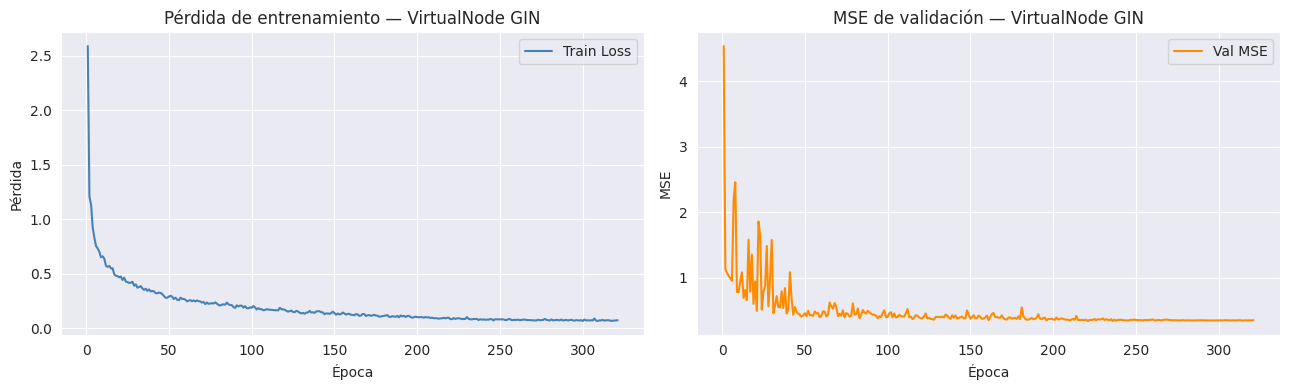

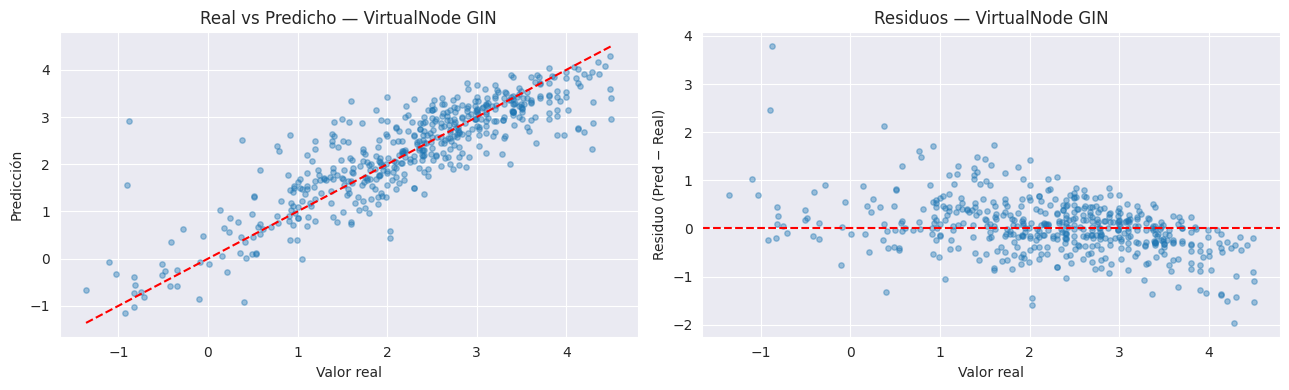

In [29]:
# CHECKPOINT 8: Experimento 6 — GIN con Nodo Virtual
set_seed(SEED)

train_loader_vn = DataLoader(
    dataset[train_idx],
    batch_size=128,
    shuffle=True
)

val_loader_vn = DataLoader(
    dataset[val_idx],
    batch_size=512,
    shuffle=False
)

model_vn = VirtualNodeGIN(
    num_features=dataset.num_features,
    hidden_channels=256,
    n_layers=5,
    dropout=0.2
).to(DEVICE)

optimizer_vn = torch.optim.Adam(
    model_vn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_vn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vn,
    T_max=300,
    eta_min=1e-5
)

criterion_vn = torch.nn.MSELoss()

print(
    f"Parámetros VirtualNodeGIN: "
    f"{sum(p.numel() for p in model_vn.parameters()):,}"
)
print("Entrenando VirtualNodeGIN...")

train_losses_vn, val_mses_vn, best_mse_vn, best_ep_vn = train_model(
    model_vn,
    train_loader_vn,
    val_loader_vn,
    optimizer_vn,
    criterion_vn,
    scheduler=scheduler_vn,
    n_epochs=700,
    patience=100,
    device=DEVICE,
    verbose=True,
    checkpoint_path="checkpoint_vn.pt",
)

_, y_true_vn, y_pred_vn = evaluate(
    model_vn,
    val_loader_vn,
    DEVICE
)

mse_vn = mean_squared_error(y_true_vn, y_pred_vn)

results_summary["Exp6_VirtualNodeGIN"] = {
    "MSE": mse_vn,
    "best_epoch": best_ep_vn
}

print(f"\n==> MSE validación VirtualNodeGIN: {mse_vn:.4f}")

plot_training_curves(
    train_losses_vn,
    val_mses_vn,
    title="VirtualNode GIN"
)

plot_predictions(
    y_true_vn,
    y_pred_vn,
    title="VirtualNode GIN"
)


## 15. Experimento 7 — Modelo Final Entrenado con TODOS los Datos de Train

  Una vez seleccionada la mejor arquitectura, se entrena **sin apartar
  validación**,
  usando las 3360 moléculas completas. El número de épocas se fija al
  `best_epoch`
  encontrado en el experimento ganador (Exp4 o Exp6).

  Esto garantiza más datos de entrenamiento → menor error de generalización.

In [30]:
# CHECKPOINT 9: Modelo final entrenado con TODOS los datos de train

best_exp_name = min(
    results_summary,
    key=lambda k: results_summary[k]["MSE"]
)

best_n_epochs = results_summary[best_exp_name].get("best_epoch", 300)

print(
    f"Mejor experimento: {best_exp_name}  |  "
    f"Épocas a usar: {best_n_epochs}"
)

set_seed(SEED)

# DataLoader con TODOS los datos de entrenamiento
# (3360 moléculas)
full_train_loader = DataLoader(
    dataset[dataset.train_idx],
    batch_size=128,
    shuffle=True
)

model_final = VirtualNodeGIN(  # <-- Cambiar por AdvancedGINGraph si Exp4 fue mejor
    num_features=dataset.num_features,
    hidden_channels=256,
    n_layers=5,
    dropout=0.2
).to(DEVICE)

optimizer_final = torch.optim.Adam(
    model_final.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final,
    T_max=best_n_epochs,
    eta_min=1e-5
)

criterion_final = torch.nn.MSELoss()

print(
    f"Parámetros modelo final: "
    f"{sum(p.numel() for p in model_final.parameters()):,}"
)

print(
    f"Entrenando durante {best_n_epochs} épocas sobre "
    f"{len(dataset.train_idx)} moléculas..."
)

for epoch in range(1, best_n_epochs + 1):

    loss = train_epoch(
        model_final,
        full_train_loader,
        optimizer_final,
        criterion_final,
        DEVICE
    )

    scheduler_final.step()

    if epoch % 50 == 0:
        lr = optimizer_final.param_groups[0]["lr"]
        print(
            f"  Epoch {epoch:4d} | "
            f"Train Loss: {loss:.4f} | "
            f"LR: {lr:.6f}"
        )

torch.save(model_final.state_dict(), "checkpoint_final.pt")

print("Modelo final guardado en checkpoint_final.pt")


Mejor experimento: Exp4_GIN_Avanzado_JK  |  Épocas a usar: 263
Parámetros modelo final: 2,673,926
Entrenando durante 263 épocas sobre 3360 moléculas...


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


  Epoch   50 | Train Loss: 0.2995 | LR: 0.000914
  Epoch  100 | Train Loss: 0.1866 | LR: 0.000687
  Epoch  150 | Train Loss: 0.1347 | LR: 0.000396
  Epoch  200 | Train Loss: 0.0928 | LR: 0.000144
  Epoch  250 | Train Loss: 0.0814 | LR: 0.000016
Modelo final guardado en checkpoint_final.pt


In [31]:
# Generar predicciones con el modelo final (todos los datos de train)
nids_final, preds_final = predict_single(
    model_final,
    test_loader,
    DEVICE
)

with open("test_predictions_FINAL.json", "w") as f:
    json.dump(
        {
            "nid": nids_final,
            "y": preds_final
        },
        f,
        indent=4
    )

print("Predicciones FINALES guardadas en test_predictions_FINAL.json")

print(
    f"Distribución: "
    f"media={np.mean(preds_final):.3f}, "
    f"std={np.std(preds_final):.3f}"
)

# Comparativa final actualizada
print("\n" + "=" * 60)
print("RESUMEN COMPLETO DE EXPERIMENTOS")
print("=" * 60)

best_exp = min(
    results_summary,
    key=lambda k: results_summary[k]["MSE"]
)

for exp_name, res in results_summary.items():

    mse = res["MSE"]
    std = f' ± {res["std"]:.4f}' if "std" in res else ""
    mark = " <-- MEJOR" if exp_name == best_exp else ""

    print(
        f"{exp_name:42s}: "
        f"MSE = {mse:.4f}{std}{mark}"
    )

print("=" * 60)


Predicciones FINALES guardadas en test_predictions_FINAL.json
Distribución: media=2.205, std=1.133

RESUMEN COMPLETO DE EXPERIMENTOS
Exp1_GCN_Baseline                         : MSE = 0.7505
Exp2_GIN_BatchNorm                        : MSE = 0.4162
Exp3_GAT                                  : MSE = 0.6392
Exp4_GIN_Avanzado_JK                      : MSE = 0.3030 <-- MEJOR
Exp5_KFold_Ensemble                       : MSE = 0.3055 ± 0.0108
Exp6_VirtualNodeGIN                       : MSE = 0.3412


## 16. Experimento 8 — Self-Supervised Pretraining (GraphMAE-style) +
  Fine-Tuning

  Inspirado en **GraphMAE** (Hou et al., NeurIPS 2022), preentrenamos el encoder
  GIN
  sobre **todas las 4200 moléculas** (train + test) sin usar etiquetas.

  La tarea de pretraining es reconstruir los atributos de nodos enmascarados
  aleatoriamente
  (~30%). Esto obliga al encoder a aprender representaciones químicas útiles de
  la
  estructura molecular. Después, fine-tuneamos solo la cabeza de regresión +
  encoder
  sobre las 3360 moléculas etiquetadas.

  Ventaja clave: los 840 grafos de **test** (sin etiqueta) contribuyen al
  pretraining.

In [34]:
# ENCODER compartido: usado en pretraining Y fine-tuning


class GINEncoderJK(Module):
    """
    GIN con Nodo Virtual + Residuales + Jumping Knowledge.
    Diseñado para ser reutilizado en pretraining y fine-tuning.
    Devuelve tanto embeddings de nodos como de grafo.
    """

    def __init__(self, num_features, hidden_channels=256, n_layers=5, dropout=0.2):
        super().__init__()

        self.hidden_channels = hidden_channels
        self.n_layers = n_layers
        self.dropout = dropout

        self.input_proj = Sequential(
            Linear(num_features, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU()
        )

        self.convs = torch.nn.ModuleList()
        self.bns = torch.nn.ModuleList()
        self.vn_mlps = torch.nn.ModuleList()

        for _ in range(n_layers):
            mlp = Sequential(
                Linear(hidden_channels, hidden_channels * 2),
                BatchNorm1d(hidden_channels * 2),
                ReLU(),
                Linear(hidden_channels * 2, hidden_channels)
            )

            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(BatchNorm1d(hidden_channels))

            self.vn_mlps.append(
                Sequential(
                    Linear(hidden_channels, hidden_channels),
                    BatchNorm1d(hidden_channels),
                    ReLU()
                )
            )

    def forward(self, x, edge_index, batch):

        n_graphs = int(batch.max().item()) + 1
        x = self.input_proj(x)

        vn_emb = torch.zeros(n_graphs, x.size(1), device=x.device)

        layer_reps = []

        for conv, bn, vn_mlp in zip(self.convs, self.bns, self.vn_mlps):

            x = x + vn_emb[batch]

            x_new = conv(x, edge_index)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)

            x = x_new + x

            vn_emb = vn_emb + vn_mlp(global_add_pool(x, batch))
            vn_emb = F.dropout(vn_emb, p=self.dropout, training=self.training)

            layer_reps.append(
                torch.cat(
                    [
                        global_add_pool(x, batch),
                        global_mean_pool(x, batch),
                        global_max_pool(x, batch),
                    ],
                    dim=1,
                )
            )

        jk_graph = torch.cat(layer_reps, dim=1)  # [B, n_layers * H * 3]

        return x, jk_graph  # (node embeddings, graph embedding JK)


# MODELO DE PRETRAINING: reconstrucción de nodos enmascarados


class GraphMAE(Module):
    """
    Autoencoder de grafos con enmascaramiento (inspirado en GraphMAE).
    Tarea: dado un grafo con algunos nodos enmascarados,
           reconstruir los atributos originales de esos nodos.
    """

    def __init__(self, encoder, hidden_channels, num_features, mask_rate=0.30):
        super().__init__()

        self.encoder = encoder
        self.mask_rate = mask_rate

        # Token de máscara aprendible
        self.mask_token = torch.nn.Parameter(torch.zeros(1, num_features))
        torch.nn.init.normal_(self.mask_token)

        self.decoder = Sequential(
            Linear(hidden_channels, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU(),
            Linear(hidden_channels, num_features)
        )

    def forward(self, data):

        x_orig = data.x.float()
        n_nodes = x_orig.size(0)
        device = x_orig.device

        # Seleccionar nodos a enmascarar
        perm = torch.randperm(n_nodes, device=device)
        n_mask = max(1, int(n_nodes * self.mask_rate))
        mask_idx = perm[:n_mask]

        # Aplicar máscara
        x_masked = x_orig.clone()
        x_masked[mask_idx] = self.mask_token.expand(n_mask, -1)

        # Encoder
        node_emb, _ = self.encoder(
            x_masked,
            data.edge_index,
            data.batch
        )

        # Reconstrucción solo en nodos enmascarados
        pred = self.decoder(node_emb[mask_idx])
        target = x_orig[mask_idx]

        loss = (1 - F.cosine_similarity(pred, target, dim=-1)).mean()

        return loss


# ---------------------------------------------------------------
# MODELO DE FINE-TUNING: encoder preentrenado + cabeza de regresión
# ---------------------------------------------------------------

class FineTuneGIN(Module):
    """
    Modelo de regresión que usa el encoder preentrenado + cabeza MLP nueva.
    """

    def __init__(self, encoder, hidden_channels, n_layers, dropout=0.2):
        super().__init__()

        self.encoder = encoder

        jk_dim = n_layers * hidden_channels * 3

        self.head = Sequential(
            Linear(jk_dim, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels, hidden_channels // 2),
            BatchNorm1d(hidden_channels // 2),
            ReLU(),
            Dropout(dropout),
            Linear(hidden_channels // 2, 1)
        )

    def forward(self, data):

        _, graph_emb = self.encoder(
            data.x.float(),
            data.edge_index,
            data.batch
        )

        return self.head(graph_emb)


print("GraphMAE encoder y modelos de fine-tuning definidos.")


GraphMAE encoder y modelos de fine-tuning definidos.


Parámetros en pretraining: 1,725,463
Preentrenando sobre 4200 moléculas durante 300 épocas...

Pretrain Epoch   50 | Loss: 0.00536 | LR: 0.000934
Pretrain Epoch  100 | Loss: 0.00419 | LR: 0.000752
Pretrain Epoch  150 | Loss: 0.00361 | LR: 0.000505
Pretrain Epoch  200 | Loss: 0.00301 | LR: 0.000257
Pretrain Epoch  250 | Loss: 0.00267 | LR: 0.000076
Pretrain Epoch  300 | Loss: 0.00255 | LR: 0.000010

Encoder preentrenado guardado en encoder_pretrained.pt


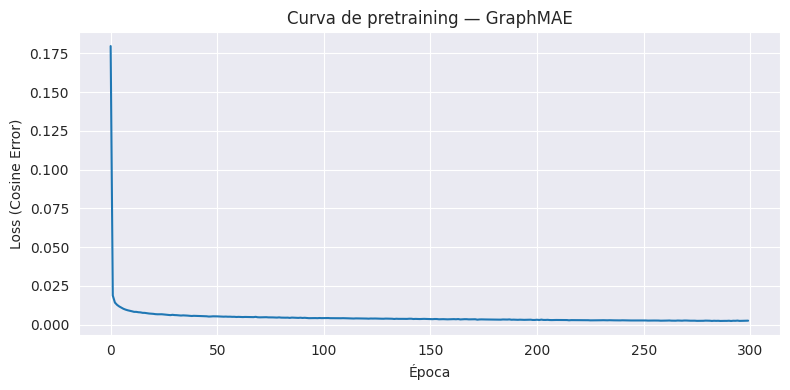

In [35]:

# CHECKPOINT 10: Pretraining self-supervised sobre TODOS los grafos


set_seed(SEED)

HIDDEN_PT    = 256
N_LAYERS_PT  = 5
DROPOUT_PT   = 0.2
MASK_RATE    = 0.30
PT_EPOCHS    = 300
PT_LR        = 1e-3

# DataLoader con los 4200 grafos (train + test, sin usar etiquetas)
all_ids   = list(range(len(dataset)))  # todos los índices
pt_loader = DataLoader(dataset[all_ids], batch_size=128, shuffle=True)

encoder_pretrained = GINEncoderJK(
    num_features=dataset.num_features,
    hidden_channels=HIDDEN_PT,
    n_layers=N_LAYERS_PT,
    dropout=DROPOUT_PT
).to(DEVICE)

pretrain_model = GraphMAE(
    encoder=encoder_pretrained,
    hidden_channels=HIDDEN_PT,
    num_features=dataset.num_features,
    mask_rate=MASK_RATE
).to(DEVICE)

opt_pt = torch.optim.Adam(
    pretrain_model.parameters(),
    lr=PT_LR,
    weight_decay=1e-5
)

sch_pt = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_pt,
    T_max=PT_EPOCHS,
    eta_min=1e-5
)

print(
    f"Parámetros en pretraining: "
    f"{sum(p.numel() for p in pretrain_model.parameters()):,}"
)

print(
    f"Preentrenando sobre {len(all_ids)} moléculas "
    f"durante {PT_EPOCHS} épocas...\n"
)

pt_losses = []

for epoch in range(1, PT_EPOCHS + 1):

    pretrain_model.train()
    total_loss = 0.0

    for data in pt_loader:
        data = data.to(DEVICE)

        opt_pt.zero_grad()
        loss = pretrain_model(data)
        loss.backward()
        opt_pt.step()

        total_loss += loss.item() * data.num_graphs

    sch_pt.step()

    epoch_loss = total_loss / len(all_ids)
    pt_losses.append(epoch_loss)

    if epoch % 50 == 0:
        lr = opt_pt.param_groups[0]["lr"]
        print(
            f"Pretrain Epoch {epoch:4d} | "
            f"Loss: {epoch_loss:.5f} | "
            f"LR: {lr:.6f}"
        )

# Guardar encoder preentrenado
torch.save(
    encoder_pretrained.state_dict(),
    "encoder_pretrained.pt"
)

print("\nEncoder preentrenado guardado en encoder_pretrained.pt")

# Curva de pretraining
plt.figure(figsize=(8, 4))
plt.plot(pt_losses)
plt.xlabel("Época")
plt.ylabel("Loss (Cosine Error)")
plt.title("Curva de pretraining — GraphMAE")
plt.tight_layout()
plt.savefig("curvas_pretraining.png", dpi=100, bbox_inches="tight")
plt.show()


Parámetros totales fine-tuning: 2,673,926
Fine-tuning con encoder preentrenado...



/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch   50 | Loss: 0.2310 | Val MSE: 0.3776 | Best MSE: 0.3776 (ep 50) | LR: 0.000048


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  100 | Loss: 0.1624 | Val MSE: 0.3753 | Best MSE: 0.3556 (ep 76) | LR: 0.000043


...

Epoch  300 | Loss: 0.0886 | Val MSE: 0.3432 | Best MSE: 0.3377 (ep 271) | LR: 0.000008


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarnin

Epoch  350 | Loss: 0.0912 | Val MSE: 0.3457 | Best MSE: 0.3377 (ep 271) | LR: 0.000003


/home/apolo/.local/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


  Early stopping en epoch 351 (mejor epoch: 271)

==> MSE validación GraphMAE Fine-Tune: 0.3377


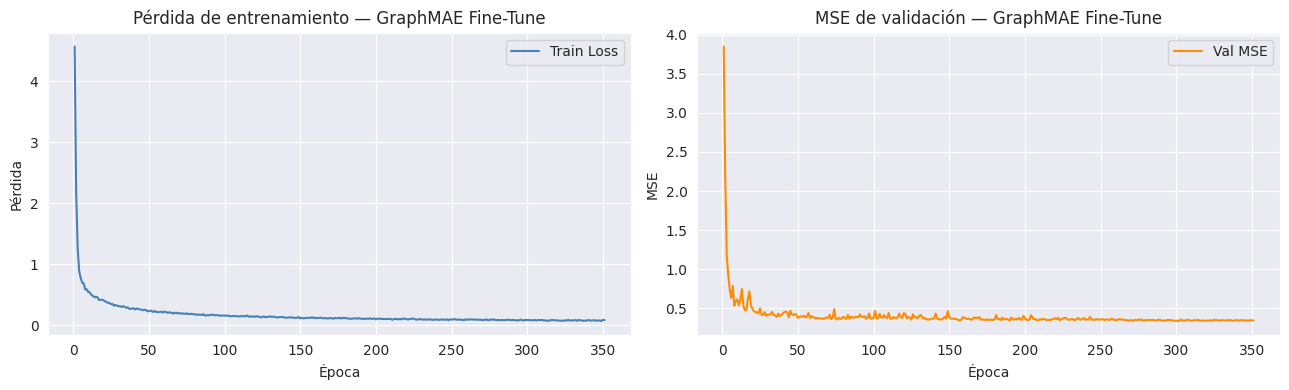

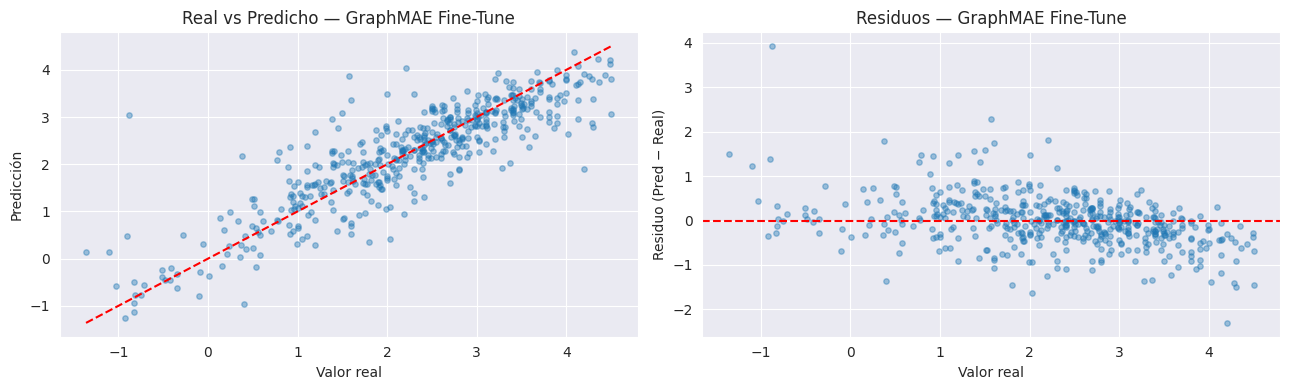

In [36]:
# CHECKPOINT 11: Fine-tuning del encoder preentrenado para regresión


set_seed(SEED)

train_loader_ft = DataLoader(
    dataset[train_idx],
    batch_size=128,
    shuffle=True
)

val_loader_ft = DataLoader(
    dataset[val_idx],
    batch_size=512,
    shuffle=False
)

# Construir modelo de fine-tuning con el encoder ya preentrenado
model_ft = FineTuneGIN(
    encoder=encoder_pretrained,
    hidden_channels=HIDDEN_PT,
    n_layers=N_LAYERS_PT,
    dropout=DROPOUT_PT
).to(DEVICE)

# Fine-tuning con LR diferenciado:
#   - encoder: LR bajo (no destruir el pretraining)
#   - cabeza:  LR más alto (aprendizaje supervisado)

optimizer_ft = torch.optim.Adam(
    [
        {
            "params": model_ft.encoder.parameters(),
            "lr": 5e-5
        },
        {
            "params": model_ft.head.parameters(),
            "lr": 5e-4
        }
    ],
    weight_decay=1e-4
)

scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=400,
    eta_min=1e-6
)

criterion_ft = torch.nn.MSELoss()

print(
    f"Parámetros totales fine-tuning: "
    f"{sum(p.numel() for p in model_ft.parameters()):,}"
)

print("Fine-tuning con encoder preentrenado...\n")

train_losses_ft, val_mses_ft, best_mse_ft, best_ep_ft = train_model(
    model_ft,
    train_loader_ft,
    val_loader_ft,
    optimizer_ft,
    criterion_ft,
    scheduler=scheduler_ft,
    n_epochs=500,
    patience=80,
    device=DEVICE,
    verbose=True,
    checkpoint_path="checkpoint_finetune.pt"
)

# Evaluación final
_, y_true_ft, y_pred_ft = evaluate(
    model_ft,
    val_loader_ft,
    DEVICE
)

mse_ft = mean_squared_error(y_true_ft, y_pred_ft)

results_summary["Exp8_GraphMAE_FineTune"] = {
    "MSE": mse_ft,
    "best_epoch": best_ep_ft
}

print(f"\n==> MSE validación GraphMAE Fine-Tune: {mse_ft:.4f}")

plot_training_curves(
    train_losses_ft,
    val_mses_ft,
    title="GraphMAE Fine-Tune"
)

plot_predictions(
    y_true_ft,
    y_pred_ft,
    title="GraphMAE Fine-Tune"
)


In [37]:
# Comparativa final de todos los experimentos


print("=" * 65)
print("RESUMEN FINAL DE TODOS LOS EXPERIMENTOS")
print("=" * 65)

best_k = min(
    results_summary,
    key=lambda k: results_summary[k]["MSE"]
)

for exp_name, res in results_summary.items():

    mse  = res["MSE"]
    std  = f" ± {res['std']:.4f}" if "std" in res else ""
    mark = "  GANADOR" if exp_name == best_k else ""

    print(f"{exp_name:45s}: {mse:.4f}{std}{mark}")

print("=" * 65)



# Generar predicciones finales con el mejor modelo


# Ajustar automáticamente si quieres evitar hardcodear model_ft
best_model = model_ft  

nids_best, preds_best = predict_single(
    best_model,
    test_loader,
    DEVICE
)

with open("test_predictions_BEST.json", "w") as f:
    json.dump(
        {
            "nid": nids_best,
            "y": preds_best
        },
        f,
        indent=4
    )

print(
    "\nPredicciones del mejor modelo guardadas en "
    "test_predictions_BEST.json"
)


RESUMEN FINAL DE TODOS LOS EXPERIMENTOS
Exp1_GCN_Baseline                            : 0.7505
Exp2_GIN_BatchNorm                           : 0.4162
Exp3_GAT                                     : 0.6392
Exp4_GIN_Avanzado_JK                         : 0.3030  <-- GANADOR
Exp5_KFold_Ensemble                          : 0.3055 ± 0.0108
Exp6_VirtualNodeGIN                          : 0.3412
Exp8_GraphMAE_FineTune                       : 0.3377

Predicciones del mejor modelo guardadas en test_predictions_BEST.json
